# Convolución de señales en recintos. 
  
 Estudiantes: Patricio Elgueda, Antonella Roco. 
 Acus099 - Procesamiento Digital de Señales
 Profesores: Victor Poblete, Felipe Figueroa.


## Introducción 
En el ámbito de la acústica, el análisis de señales de audio permite comprender cómo el sonido se comporta en distintos entornos. Un concepto fundamental en este contexto es la respuesta al impulso, la cual describe cómo un recinto modifica una señal sonora al propagarse en su interior.

En el  trabajo se analiza la respuesta al impulso en distintos recintos de la Universidad Austral de Chile y de la ciudad de Valdivia, conforme a la norma ISO 3382. El propósito es comprender de qué manera las características acústicas de cada espacio influyen en la percepción sonora, a partir de la captura de respuestas al impulso y su aplicación a señales anecoicas de voz e instrumentos musicales.

La metodologia empleada, en primer lugar, la grabación de señales en cámara anecoica. Posteriormente, se realiza la medición de las respuestas al impulso en tres recintos seleccionados. Finalmente, se lleva a cabo la convolución de dichas respuestas con las señales originales, con el fin de simular cómo se percibiría una fuente sonora dentro de cada uno de los espacios analizados.

## Teoría

La convolución es una operación matemática fundamental en el procesamiento de señales. En el contexto acústico, permite determinar la salida de un sistema lineal e invariante en el tiempo (LTI) a partir de una señal de entrada y de su respuesta al impulso.

$$
y(t) = x(t) * h(t)
$$

### Donde:

- x(t): señal de entrada (voz o instrumento en condiciones anecoicas)
- h(t): respuesta al impulso del recinto
- y(t): señal de salida o señal convolucionada


 La respuesta al impulso de un recinto contiene información relevante sobre sus propiedades acústicas, entre las que destacan las reflexiones tempranas, la reverberación y la absorción del espacio.

 Al realizar la convolución entre la señal de entrada y la respuesta al impulso, se obtiene una representación que simula de manera realista cómo el sonido interactúa con el entorno. Esto permite analizar y predecir la percepción sonora en distintos recintos sin necesidad de realizar mediciones directas en cada caso.

## ISO3382

En la presente práctica se adoptó la norma ISO 3382 como referencia para la medición de la respuesta al impulso en los recintos analizados. Dicha norma establece procedimientos estandarizados para la evaluación del comportamiento acústico en espacios cerrados, permitiendo la obtención de parámetros como el tiempo de reverberación y la claridad del sonido.

 Su aplicación resulta fundamental, ya que asegura que las mediciones sean confiables, consistentes y comparables, proporcionando así un marco metodológico sólido para el desarrollo del análisis acústico.



# Desarollo 

### Mediciones en terreno
En este procedimiento se utilizó, como equipamiento para las mediciones, los siguientes instrumentos: 
 - Micrófono condensador Behringer ecm8000 
 - Atril para micrófono 
 -Interfaz Focusrite 2i4
 - Computador 
 - Claqueta 

<div align="center">
    <img src="../assets/images/equipamiento_00.jpeg" width="250">
</div>

### Audios 

Camara anecóica: en este lugar se grabó voz masculina de Patricio con un estracto de la canción "Como te extraño mi amor" que se reconocera como un color naranjo en los gráficos.


<div align="center">
    <img src="../assets/images/patricio_voz_anecoica_00.jpeg" width="250">
</div>


También se grabó como instrumento una ocarina que se reconoce por el color morado en los gráficos.

<div align="center">
    <img src="../assets/images/anto_ocarina_anecoica_00.jpeg" width="350">
</div>



### Reverberante 

- Fue el primer recinto donde se graba respuesta de impulso, representado con el color amarillo. 
"insertar audio e imagen" 

 
 

<div align="center">
    <img src="../assets/images/reverberante.jpg" width="350">
</div>


### Sala 11101 Ed.11k:

- Segundo recinto de grabación, representado por el color verde. 

<div align="center">
    <img src="../assets/images/imagen_sala11101_00.jpeg" width="350">
</div>

 

### Sala 9202 Ed.9k: 

- Tercer recinto de grabación, representado por el color azul. 

<div align="center">
    <img src="../assets/images/imagen_sala9202_00.jpeg" width="350">
</div>

## Convolución de señales 
Para el proceso de convolución de las señales grabadas, se utiliza el lenguaje de python a través del siguiente código.

### Importación de librerias


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
from scipy.signal import fftconvolve
from IPython.display import Audio, display


### Importación de audios (subir cada audio en seco, con graficos etc)

In [2]:
ruta_voz = Path("../assets/audio/patricio_voz_anecoica.wav")
ruta_ocarina = Path("../assets/audio/ocarina_anecoica_00.wav")
voz, fs_voz = sf.read(ruta_voz)
ocarina, fs_ocarina = sf.read(ruta_ocarina)
t_voz = np.arange(len(voz)) / fs_voz
t_ocarina = np.arange(len(ocarina)) / fs_ocarina

Voz original:


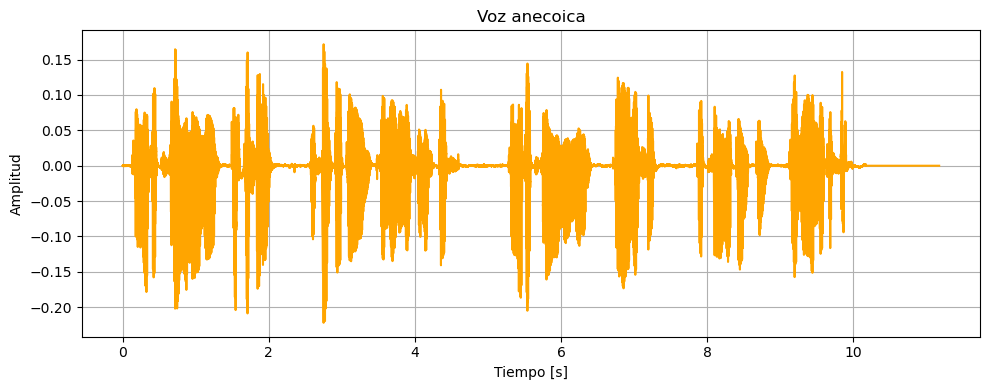

In [ ]:
voz, fs_voz = librosa.load(ruta_voz, sr=None)

print("Voz original:")
display(Audio(voz, rate=fs_voz))

plt.figure(figsize=(10, 4))
plt.plot(t_voz, voz, color="orange")
plt.title("Voz anecoica")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.tight_layout()
plt.show()

Ocarina original:


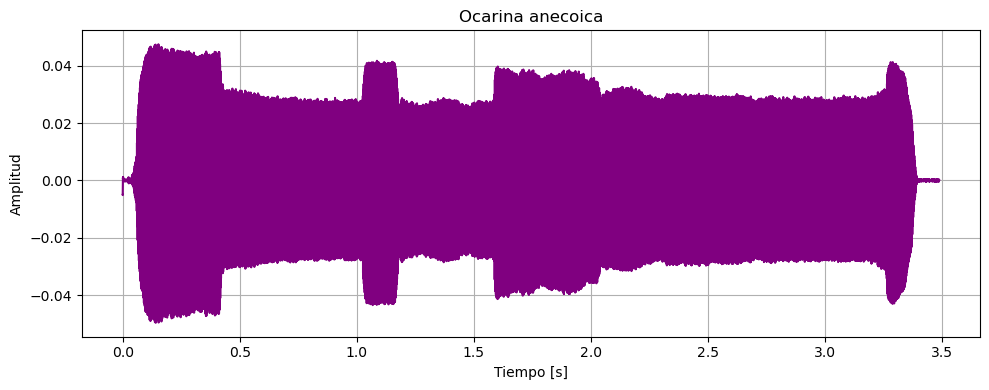

In [ ]:
ocarina, fs_ocarina = librosa.load(ruta_ocarina, sr=None)

print("Ocarina original:")
display(Audio(ocarina, rate=fs_ocarina))

plt.figure(figsize=(10, 4))
plt.plot(t_ocarina, ocarina, color="purple")
plt.title("Ocarina anecoica")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.tight_layout()
plt.show()

### Respuesta impulso salas

In [9]:
# Cargar la respuesta al impulso de la sala
ruta_sala_1 = Path("../assets/audio/reverberante_00.wav")
sala_1, fs_sala_1 = librosa.load(ruta_sala_1, sr=None)

ruta_sala_2 = Path("../assets/audio/sala_11101_00.wav")
sala_2, fs_sala_2 = librosa.load(ruta_sala_2, sr=None)

ruta_sala_3 = Path("../assets/audio/sala_9202_00.wav")
sala_3, fs_sala_3 = librosa.load(ruta_sala_3, sr=None)


#### SALA 1: Reverberante

Respuesta al impulso de la sala 1:


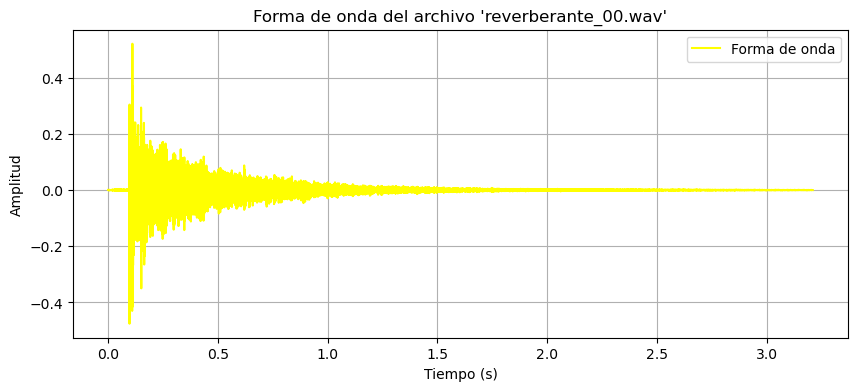

In [10]:
time_1 = np.linspace(0, len(sala_1) / fs_sala_1, num=len(sala_1))  
print("Respuesta al impulso de la sala 1:")
plt.figure(figsize=(10, 4))
plt.plot(time_1, sala_1, label="Forma de onda", color="yellow")
plt.title("Forma de onda del archivo 'reverberante_00.wav'")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()

#### Sala 2: Sala 11.101

Respuesta al impulso de la sala 2:


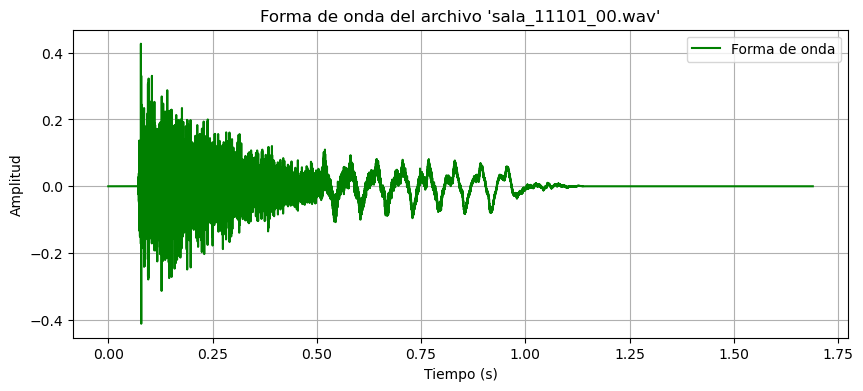

In [11]:
time_2 = np.linspace(0, len(sala_2) / fs_sala_2, num=len(sala_2))  
print("Respuesta al impulso de la sala 2:")
plt.figure(figsize=(10, 4))
plt.plot(time_2, sala_2, label="Forma de onda", color="green")
plt.title("Forma de onda del archivo 'sala_11101_00.wav'")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()

#### Sala 3: Sala 9202

Respuesta al impulso de la sala 3:


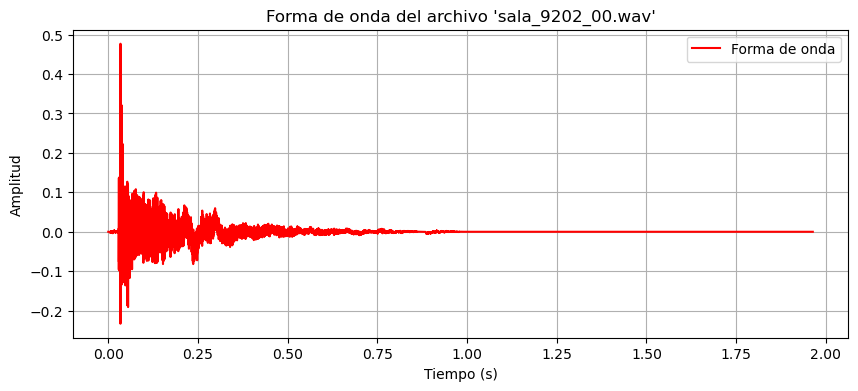

In [12]:
time_3 = np.linspace(0, len(sala_3) / fs_sala_3, num=len(sala_3))  
print("Respuesta al impulso de la sala 3:")
plt.figure(figsize=(10, 4))
plt.plot(time_3, sala_3, label="Forma de onda", color="red")
plt.title("Forma de onda del archivo 'sala_9202_00.wav'")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()

### Convolución de las señales

In [13]:
# Convolución
conv_voz_1 = fftconvolve(voz, sala_1, mode="full")
conv_voz_2 = fftconvolve(voz, sala_2, mode="full")
conv_voz_3 = fftconvolve(voz, sala_3, mode="full")
conv_ocarina_1 = fftconvolve(ocarina, sala_1, mode="full")
conv_ocarina_2 = fftconvolve(ocarina, sala_2, mode="full")
conv_ocarina_3 = fftconvolve(ocarina, sala_3, mode="full")

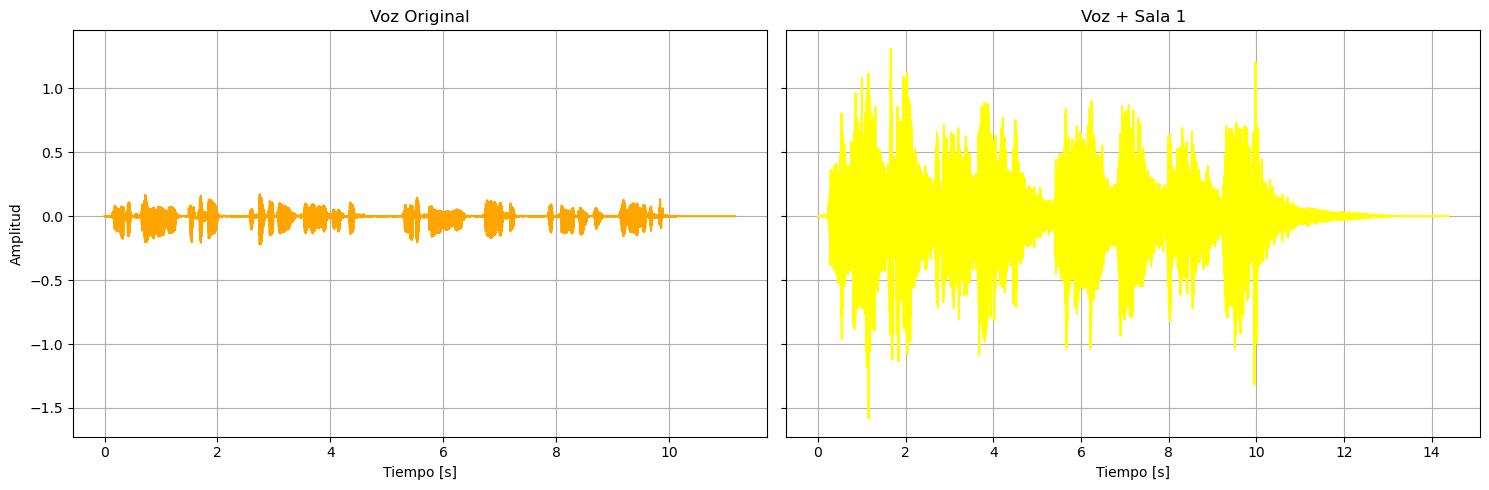

In [ ]:
#voz sala 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

ax1.plot(t_voz, voz, color="orange")
ax1.set_title("Voz Original")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud")
ax1.grid(True)

t_conv_voz_1 = np.arange(len(conv_voz_1)) / fs_sala_1
ax2.plot(t_conv_voz_1, conv_voz_1, color="yellow")
ax2.set_title("Voz + Sala 1")
ax2.set_xlabel("Tiempo [s]")
ax2.grid(True)

plt.tight_layout()
plt.show()

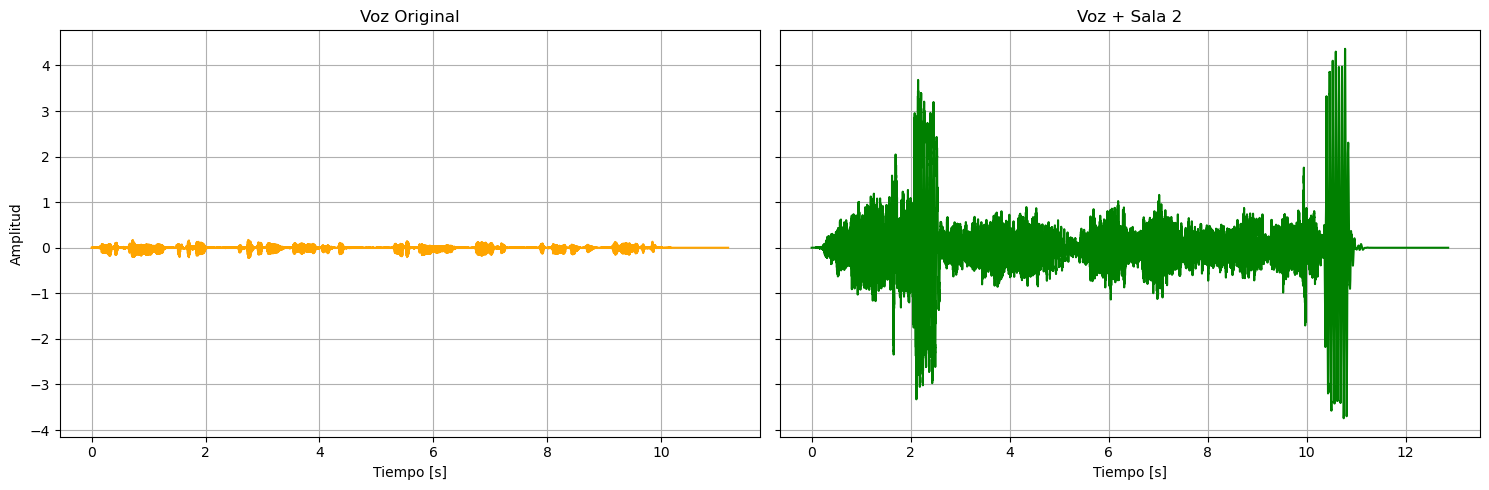

In [ ]:
#voz sala 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

ax1.plot(t_voz, voz, color="orange")
ax1.set_title("Voz Original")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud")
ax1.grid(True)

t_conv_voz_2 = np.arange(len(conv_voz_2)) / fs_sala_2
ax2.plot(t_conv_voz_2, conv_voz_2, color="green")
ax2.set_title("Voz + Sala 2")
ax2.set_xlabel("Tiempo [s]")
ax2.grid(True)

plt.tight_layout()
plt.show()

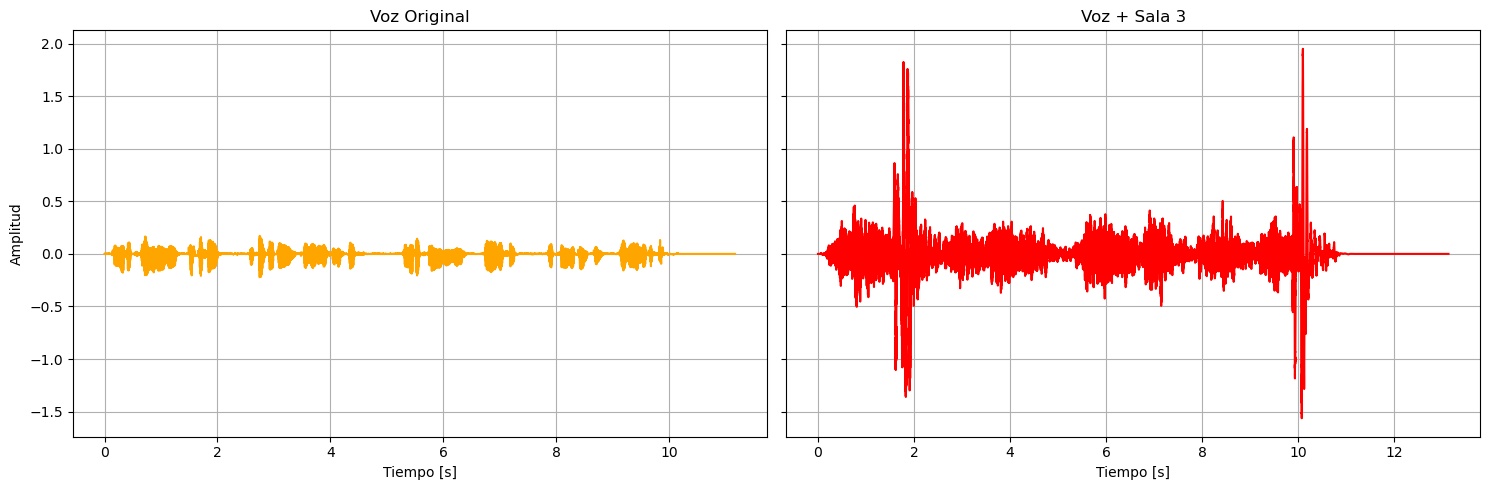

In [ ]:
#voz sala 3

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

ax1.plot(t_voz, voz, color="orange")
ax1.set_title("Voz Original")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud")
ax1.grid(True)

t_conv_voz_3 = np.arange(len(conv_voz_3)) / fs_sala_3
ax2.plot(t_conv_voz_3, conv_voz_3, color="red")
ax2.set_title("Voz + Sala 3")
ax2.set_xlabel("Tiempo [s]")
ax2.grid(True)

plt.tight_layout()
plt.show()

### Convolucion de la ocarina en cada recinto 

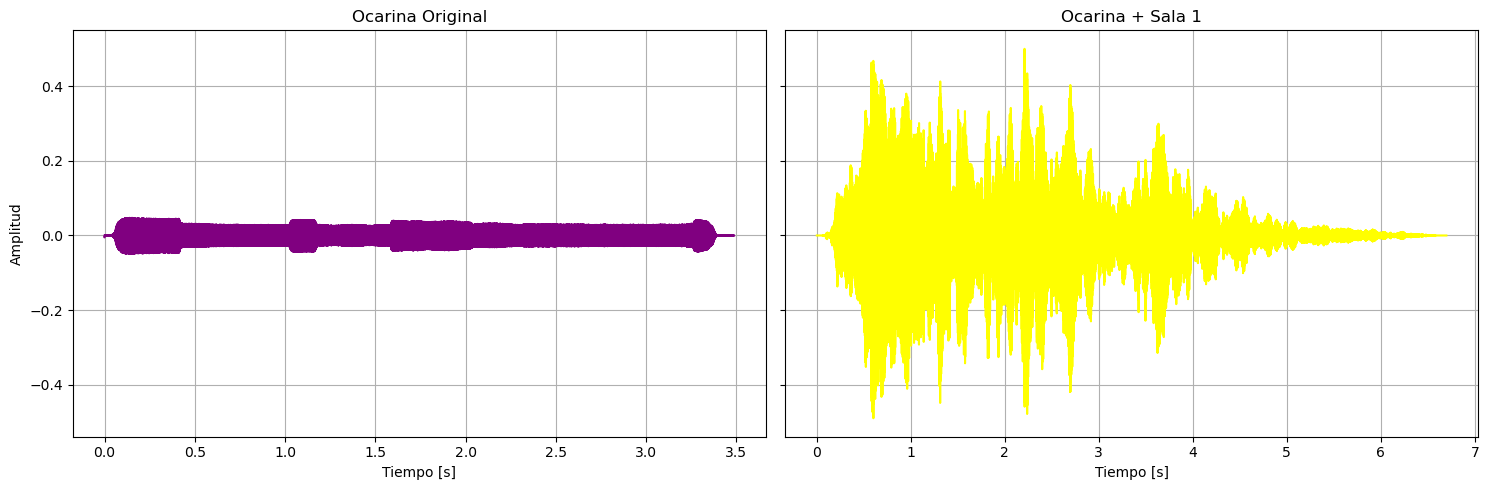

In [ ]:
#ocarina sala 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

ax1.plot(t_ocarina, ocarina, color="purple")
ax1.set_title("Ocarina Original")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud")
ax1.grid(True)

t_conv_ocarina_1 = np.arange(len(conv_ocarina_1)) / fs_sala_1
ax2.plot(t_conv_ocarina_1, conv_ocarina_1, color="yellow")
ax2.set_title("Ocarina + Sala 1")
ax2.set_xlabel("Tiempo [s]")
ax2.grid(True)

plt.tight_layout()
plt.show()

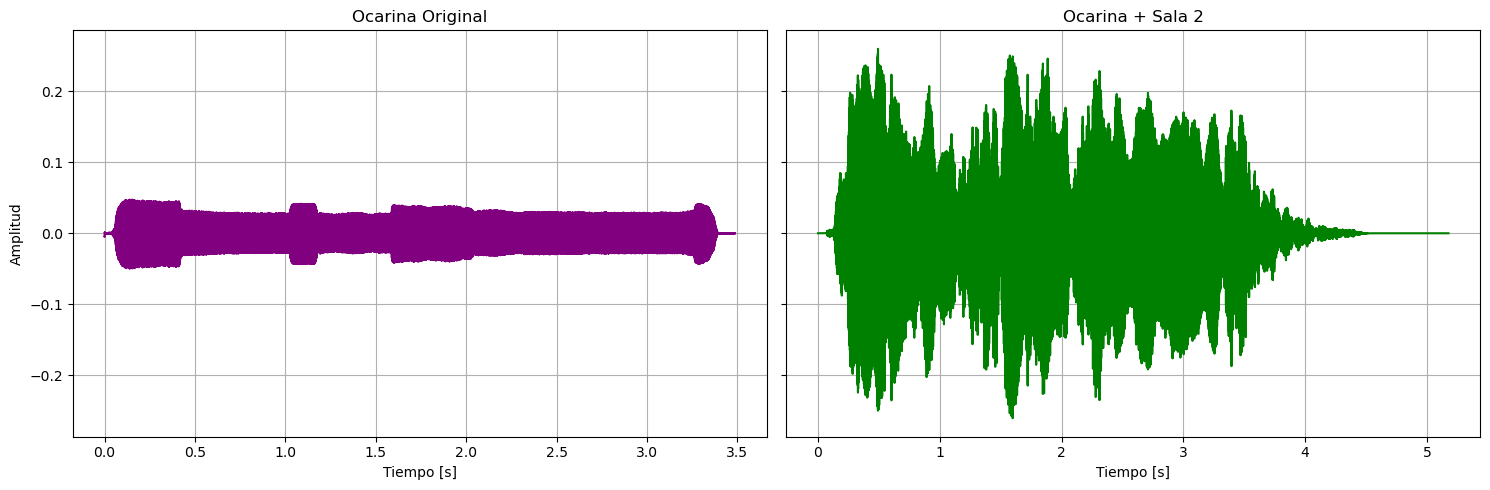

In [ ]:
#ocarina sala 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

ax1.plot(t_ocarina, ocarina, color="purple")
ax1.set_title("Ocarina Original")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud")
ax1.grid(True)

t_conv_ocarina_2 = np.arange(len(conv_ocarina_2)) / fs_sala_2
ax2.plot(t_conv_ocarina_2, conv_ocarina_2, color="green")
ax2.set_title("Ocarina + Sala 2")
ax2.set_xlabel("Tiempo [s]")
ax2.grid(True)

plt.tight_layout()
plt.show()


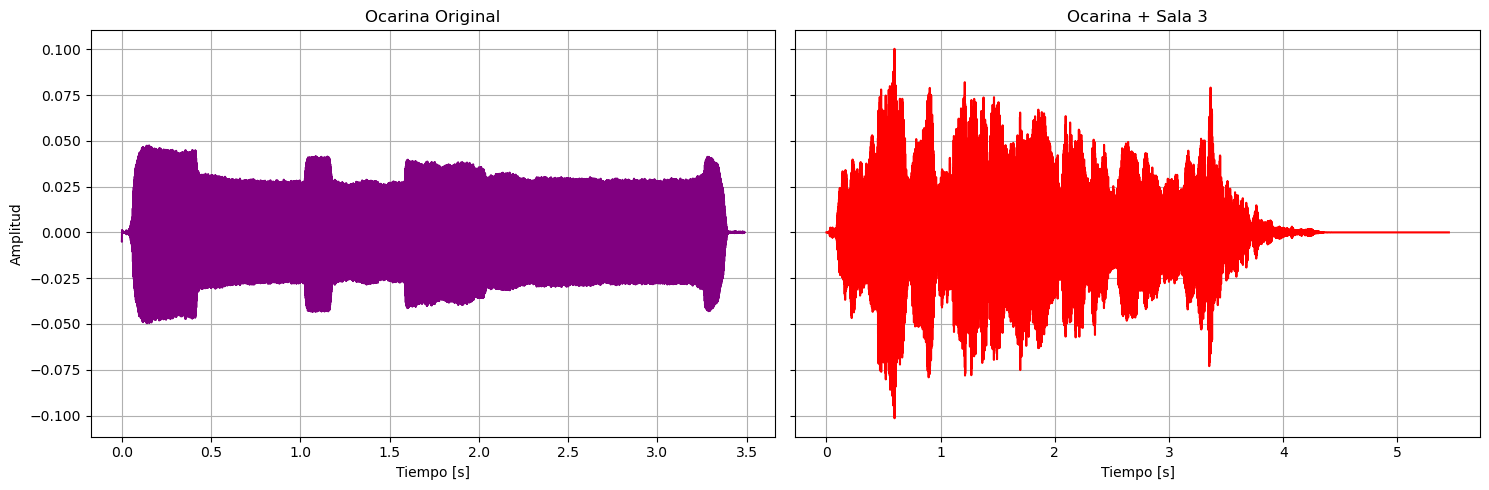

In [ ]:
#ocarina sala 3

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
t_conv_ocarina_3 = np.arange(len(conv_ocarina_3)) / fs_sala_3
ax1.plot(t_ocarina, ocarina, color="purple")
ax1.set_title("Ocarina Original")
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud")
ax1.grid(True)

ax2.plot(t_conv_ocarina_3, conv_ocarina_3, color="red")
ax2.set_title("Ocarina + Sala 3")
ax2.set_xlabel("Tiempo [s]")
ax2.grid(True)

plt.tight_layout()
plt.show()

## Conclusión

La práctica permitió evidenciar cómo cada recinto modifica de manera particular las características de una señal sonora. Mediante la convolución, se observó que tanto la voz como el instrumento adquieren propiedades acústicas propias de cada espacio, destacando la importancia de la respuesta al impulso en el análisis, diseño y evaluación de salas.

Durante el desarrollo de las mediciones se presentaron algunas dificultades, entre ellas la presencia de ruidos externos, además de la variabilidad de las condiciones ambientales en cada recinto. No obstante, la aplicación de la norma ISO 3382 permitió estandarizar el procedimiento de medición, asegurando la repetibilidad de los registros y la obtención de resultados confiables y comparables entre los distintos espacios analizados.

Finalmente, el uso de recursos audiovisuales y representaciones gráficas facilitó la comprensión de los fenómenos acústicos observados, contribuyendo a una presentación clara, organizada y acorde con los criterios de calidad establecidos para la actividad.